# 02 — Forward Propagation (PyTorch)

We trace one real MNIST image through a deliberately tiny **784 → 4 → 10** network so every intermediate quantity remains inspectable.


## Equations
$$z^{(1)}=xW^{(1)}+b^{(1)},\quad a^{(1)}=\operatorname{ReLU}(z^{(1)})$$
$$z^{(2)}=a^{(1)}W^{(2)}+b^{(2)},\quad \hat y=\operatorname{softmax}(z^{(2)})$$

A matrix multiplication is just many scalar multiply-add operations executed together.


train (5000, 784) test (1000, 784)


true 0
z1 tensor([[ 0.0894,  0.1572,  0.4728, -0.2337]])
manual h0 0.08940866589546204 matrix 0.08940870314836502
p tensor([[0.0995, 0.1039, 0.1031, 0.0999, 0.1018, 0.0986, 0.0975, 0.0975, 0.0983,
         0.0999]]) pred 1


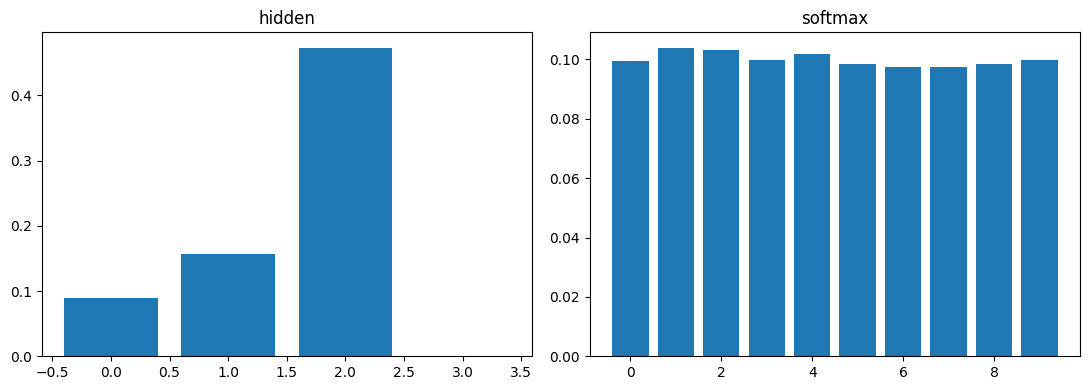

In [1]:
from pathlib import Path
import urllib.request, numpy as np
MNIST_URL='https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz'
CACHE=Path('data/cache/mnist.npz'); CACHE.parent.mkdir(parents=True,exist_ok=True)
if not CACHE.exists():
    print('Downloading official MNIST archive...')
    urllib.request.urlretrieve(MNIST_URL,CACHE)
with np.load(CACHE) as d:
    x_train_full,y_train_full=d['x_train'],d['y_train']
    x_test_full,y_test_full=d['x_test'],d['y_test']
def balanced(x,y,n):
    ids=np.concatenate([np.flatnonzero(y==c)[:n] for c in range(10)])
    return x[ids],y[ids]
x_train_img,y_train=balanced(x_train_full,y_train_full,500)
x_test_img,y_test=balanced(x_test_full,y_test_full,100)
x_train=x_train_img.reshape(len(x_train_img),-1).astype('float32')/255.0
x_test=x_test_img.reshape(len(x_test_img),-1).astype('float32')/255.0
print('train',x_train.shape,'test',x_test.shape)

import torch,matplotlib.pyplot as plt
torch.manual_seed(42);X=torch.tensor(x_train[:1]);W1=torch.randn(784,4)*.03;b1=torch.zeros(4);W2=torch.randn(4,10)*.05;b2=torch.zeros(10);z1=X@W1+b1;a1=torch.relu(z1);q=a1@W2+b2;p=torch.softmax(q,1);manual=(X[0]*W1[:,0]).sum()+b1[0];print('true',int(y_train[0]));print('z1',z1);print('manual h0',manual.item(),'matrix',z1[0,0].item());print('p',p,'pred',p.argmax(1).item());fig,axes=plt.subplots(1,2,figsize=(11,4));axes[0].bar(range(4),a1[0].numpy());axes[1].bar(range(10),p[0].numpy());axes[0].set_title('hidden');axes[1].set_title('softmax');plt.tight_layout();plt.show()


**Inference:** no learning happens during forward propagation. With fixed inputs and parameters, the prediction is deterministic. The hidden activation vector is the current learned representation of the image.
